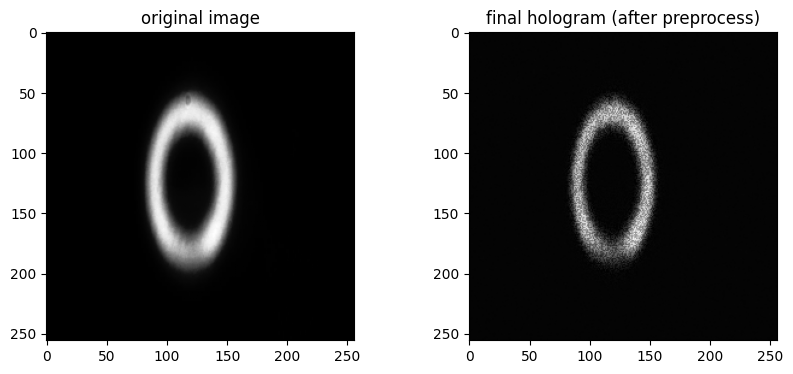

In [13]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms


def simulate_qiup_hologram(amplitude,
                           rp=0.5,
                           ri=0.5,
                           gamma=0.5,
                           noise_std=0.002):  # aumentando la stddev del ruido

    # random phase
    phi = torch.rand_like(amplitude) * (2 * math.pi)

    rs = amplitude

    # hologram interference model
    hologram = rp**2 + rs**2 + 2 * rp * rs * ri * gamma * torch.cos(phi)

    # noise with higher intensity
    noise = noise_std * torch.randn_like(hologram) * torch.sign(torch.randn_like(hologram))  # Adjusting noise
    hologram = hologram + noise

    # normalize
    hologram = (hologram - hologram.min()) / (hologram.max() - hologram.min() + 1e-8)

    return hologram


# ---------- load image ----------
img = Image.open("image.png").convert("L")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

amp = transform(img)

# ---------- generate final hologram ----------
hologram = simulate_qiup_hologram(amp)

# ---------- show ----------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("original image")
plt.imshow(amp.squeeze(), cmap="gray")

plt.subplot(1, 2, 2)
plt.title("final hologram (after preprocess)")
plt.imshow(hologram.squeeze(), cmap="gray")

plt.show()

# optional save
holo_np = (hologram.squeeze().numpy() * 255).astype(np.uint8)
Image.fromarray(holo_np).save("generated_hologram.png")
